## Lab 23 Evaluacion de Modelos de regresion 
##  MAE, MSE, RMSE, R2

In [15]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression 

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,  # <--- Corregido 'men' por 'mean'
    r2_score
)

In [16]:
diabetes = load_diabetes(as_frame = True)
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [17]:
df=diabetes.frame 

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [19]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


## seleccion de variables predictoras y variables objetivo 
## hipotesis 
existe una relacion entre las variables clinicas del pasiente y la propagacion de la diabetes 1 año despues 

In [20]:
#predictora 

X = df.drop(columns="target")

In [21]:

y = df["target"]

In [22]:
X.head()
y.head()

0    151.0
1     75.0
2    141.0
3    206.0
4    135.0
Name: target, dtype: float64

## Separacion de datos para entrenamiento y prueba 

In [23]:
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size = 0.3,
        random_state= 42
    )

In [24]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

LinearRegression()

Predicsiones 

In [25]:
prediccion = modelo.predict(X_test)

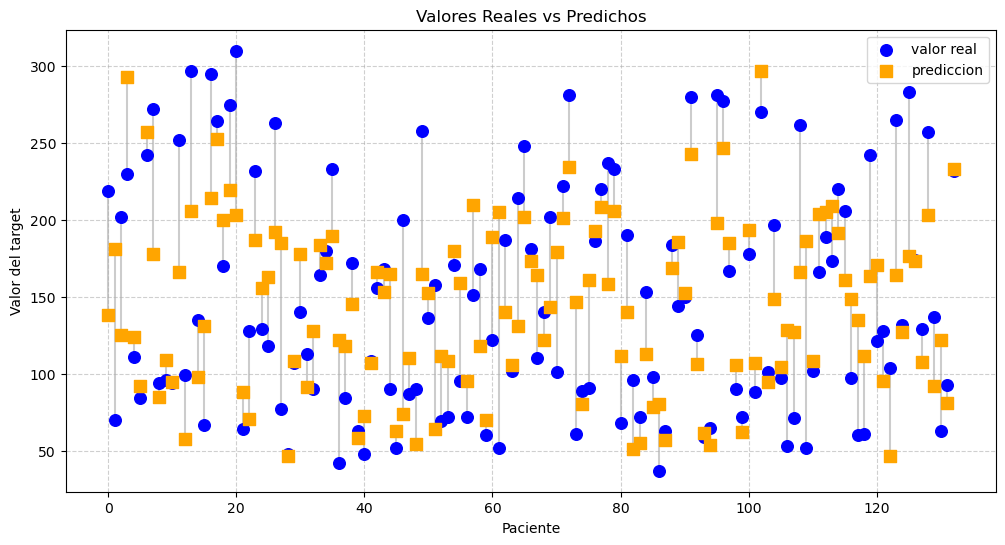

In [29]:
import matplotlib.pyplot as plt

# Creamos el DataFrame de comparación
comparacion = pd.DataFrame({
    "real": y_test.values,
    "prediccion": prediccion,
}).reset_index(drop=True)

# Inicializamos la gráfica
plt.figure(figsize=(12, 6))

# 1. Dibujamos SOLO las líneas grises de error dentro del bucle
for i in range(len(comparacion)):
    plt.plot(
        [i, i],
        [comparacion["real"][i], comparacion["prediccion"][i]], # Corregido "comparacio"
        color="gray",
        alpha=0.4,
        zorder=1 # Envía las líneas al fondo
    )

# 2. Dibujamos los puntos una sola vez (FUERA del bucle for)
plt.scatter(
    comparacion.index,
    comparacion["real"],
    label="valor real",
    marker="o",
    s=70,
    color="blue",
    zorder=2 # Coloca los puntos encima de las líneas
)

plt.scatter(
    comparacion.index,
    comparacion["prediccion"],
    label="prediccion",
    marker="s",
    s=70,
    color="orange",
    zorder=2
)

# Personalización de la gráfica
plt.xlabel("Paciente")
plt.ylabel("Valor del target")
plt.title("Valores Reales vs Predichos")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

## Metricas 

In [32]:
mae = mean_absolute_error(
    y_test,
    prediccion
)

In [33]:
print(f"mae:{mae: .2f}")

mae: 41.92


In [34]:
mse = mean_squared_error(
     y_test,
    prediccion
)

In [37]:
print(f"mse:{mse: .2f}")

mse: 2821.75


In [38]:
rmse = root_mean_squared_error(
    y_test,
    prediccion
)

In [39]:
print(f"rmse:{rmse: .2f}")

rmse: 53.12


In [40]:
#coeficiente de determinacion (r2)

r2 = r2_score(
     y_test,
    prediccion
)

In [41]:
print(f"r2:{r2: .2f}")

r2: 0.48
